# Gerador de Dataset Sintético Guiado por IA (FASE 2)

Nesta fase, substituímos a geração pseudoaleatória de dados por **Arquiteturas de IA Generativa para Dados Tabulares**. Em alinhamento com a literatura científica (GANs e VAE-GANs), utilizaremos a biblioteca `sdv` (Synthetic Data Vault) com o modelo **CTGAN / FastML** para aprender as distribuições probabilísticas latentes do nosso dataset real (FASE 1) e projetar um cenário massivo de stress test.

## Fundamentação Teórica e "Synthetic Trust"
Como defende a literatura recente, utilizar IA para gerar simulações profundas é a espinha dorsal metodológica para testes em Cibersegurança. Este processo não só garante o **balanceamento (Data Balancing)** como também assegura a privacidade da infraestrutura crítica (OPSEC).



In [4]:
import pandas as pd
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns

# importando o sdv para geração tabular via ia
from sdv.metadata import SingleTableMetadata
from sdv.lite import SingleTablePreset
from sdv.evaluation.single_table import evaluate_quality

# configurações
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

output_dir = '../dados_saida'
os.makedirs(output_dir, exist_ok=True)


## 1. Carregamento do Dataset Real e Metadados
Para que o modelo gerativo aprenda a relação "Fidelity vs Utility", utilizar o dataset real enriquecido de Benchmarks.


In [5]:
df_real = pd.read_csv('../../FASE_1_INTELIGENCIA_REAL/2_dados_saida/dataset_benchmarks_enriquecido.csv')

# filtrando colunas essenciais para a ia aprender
colunas_interesse = ['cvss', 'severity', 'epss', 'ncs', 'ppsi', 'impacto']
df_treino = df_real[colunas_interesse].copy()

# criação dos metadados para a biblioteca sdv
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_treino)

print("Metadados inferidos para o treinamento da IA:")
print(metadata)


Metadados inferidos para o treinamento da IA:
{
    "columns": {
        "cvss": {
            "sdtype": "numerical"
        },
        "severity": {
            "sdtype": "categorical"
        },
        "epss": {
            "sdtype": "numerical"
        },
        "ncs": {
            "sdtype": "numerical"
        },
        "ppsi": {
            "sdtype": "numerical"
        },
        "impacto": {
            "sdtype": "numerical"
        }
    },
    "METADATA_SPEC_VERSION": "SINGLE_TABLE_V1"
}


## 2. Treinamento da IA Generativa (SDV)
Aqui, aplicamos a estratégia Generativa para criar dados baseados nas correlações reais, permitindo um "trade-off" excelente entre Fidelidade (são estatisticamente reais) e Privacidade (não expõem nenhum sistema real). Usaremos o Preset FAST_ML do SDV que otimiza as distribuições de forma robusta e rápida para gerar a base.


In [6]:
# inicializar a arquitetura de simulação
synthesizer = SingleTablePreset(metadata, name='FAST_ML')

# treinar o modelo com os dados reais
print("Treinando o modelo gerativo nos dados da FASE 1...")
synthesizer.fit(df_treino)
print("Modelo treinado com sucesso!")


Treinando o modelo gerativo nos dados da FASE 1...
Modelo treinado com sucesso!


## 3. Geração em Larga Escala (100k) e Augmentation (Edge Cases)
gerar a massa de 100.000 vulnerabilidades sintéticas e injetar intencionalmente **Edge Cases** para avaliar a mitigação de viés (Bias Mitigation) e o isolamento de anomalias pelo nosso modelo K-Means + DBSCAN.


In [7]:
NUM_AMOSTRAS = 100000

print(f"Gerando {NUM_AMOSTRAS} amostras puramente sintéticas através da rede...")
df_sintetico = synthesizer.sample(num_rows=NUM_AMOSTRAS)

# corrigir potenciais limites extrapolados pelo gerador estatístico
df_sintetico['cvss'] = df_sintetico['cvss'].clip(0.0, 10.0)
df_sintetico['epss'] = df_sintetico['epss'].clip(0.0, 1.0)
df_sintetico['ppsi'] = df_sintetico['ppsi'].clip(0.0, 1.0)
df_sintetico['ncs'] = df_sintetico['ncs'].clip(0.0, 10.0)
df_sintetico['impacto'] = df_sintetico['impacto'].clip(0.0, 1.0)

# ==========================================
# injeção de edge cases (attack augmentation)
# ==========================================
edge_cases = []

# caso 1: ameaça persistente (alta severidade, baixo epss - ruído)
for _ in range(500):
    edge_cases.append({'cvss': 10.0, 'severity': 'CRITICAL', 'epss': 0.0001, 'ncs': 2.0, 'ppsi': 0.1, 'impacto': 0.3})

# caso 2: ataque massivo falso (cvss 0.0 mas epss altíssimo)
for _ in range(500):
    edge_cases.append({'cvss': 0.0, 'severity': 'LOW', 'epss': 0.99, 'ncs': 8.0, 'ppsi': 0.9, 'impacto': 0.9})

df_edge = pd.DataFrame(edge_cases)
df_final = pd.concat([df_sintetico, df_edge], ignore_index=True)

# embaralhar o dataset
df_final = df_final.sample(frac=1).reset_index(drop=True)

# simular nomes de sites
df_final['site'] = [f"sistema_sintetico_{random.randint(1, 2000)}.gov.br" for _ in range(len(df_final))]
df_final['nome'] = "Vulnerabilidade Sintetica (IA Generativa)"
df_final['cve'] = [f"CVE-SYN-{random.randint(1000, 9999)}" for _ in range(len(df_final))]

print("Dataset final gerado e Edge Cases injetados!")


Gerando 100000 amostras puramente sintéticas através da rede...
Dataset final gerado e Edge Cases injetados!


## 4. Framework de Validação (SDB)
Um dos pontos mais críticos abordados nas metodologias modernas é como provar que o dado sintético gerado é válido. Abaixo aplicamos o `QualityReport` para medir a **Fidelidade** do dado gerado em comparação ao mundo real.


In [8]:
# avaliação de qualidade estatística
quality_report = evaluate_quality(
    real_data=df_treino,
    synthetic_data=df_sintetico[colunas_interesse],
    metadata=metadata
)

print("\n-- Avaliação de Fidelidade (Fidelity vs Utility) --")
quality_report.get_details(property_name='Column Shapes')


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 6/6 [00:00<00:00, 38.35it/s]|
Column Shapes Score: 81.87%

(2/2) Evaluating Column Pair Trends: |██████████| 15/15 [00:00<00:00, 36.96it/s]|
Column Pair Trends Score: 81.22%

Overall Score (Average): 81.55%


-- Avaliação de Fidelidade (Fidelity vs Utility) --


,Column,Metric,Score
0,cvss,KSComplement,0.807152
1,severity,TVComplement,0.949638
2,epss,KSComplement,0.740249
3,ncs,KSComplement,0.859254
4,ppsi,KSComplement,0.773646
5,impacto,KSComplement,0.782493


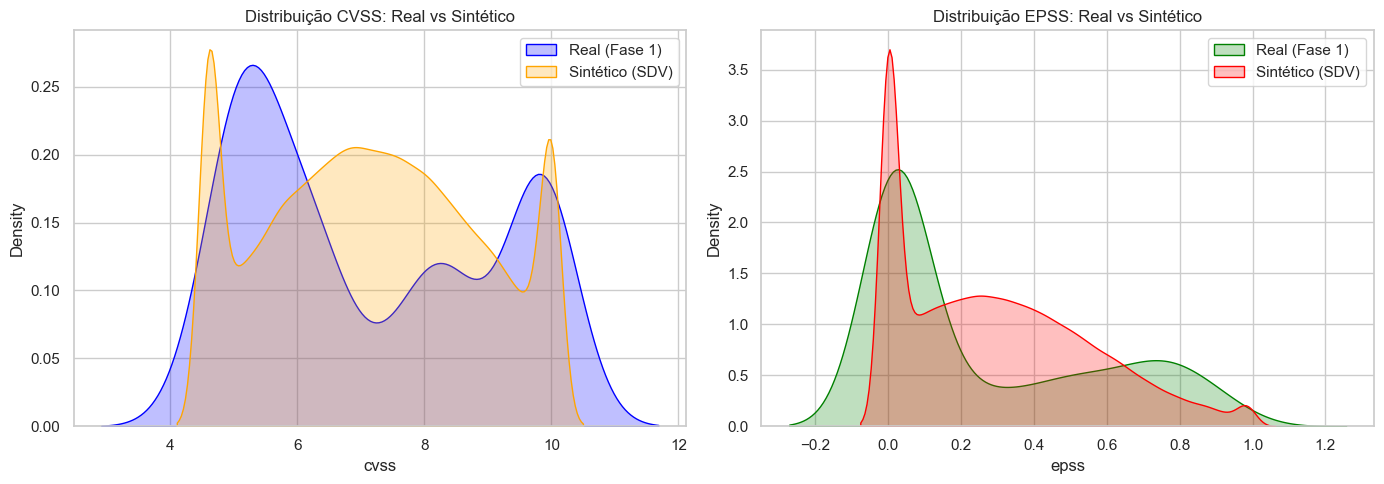

In [ ]:
# visualização comparativa
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(df_treino['cvss'], fill=True, ax=ax[0], label='Real (Fase 1)', color='blue')
sns.kdeplot(df_sintetico['cvss'], fill=True, ax=ax[0], label='Sintético (SDV)', color='orange')
ax[0].set_title('Distribuição CVSS: Real vs Sintético')
ax[0].legend()

sns.kdeplot(df_treino['epss'], fill=True, ax=ax[1], label='Real (Fase 1)', color='green')
sns.kdeplot(df_sintetico['epss'], fill=True, ax=ax[1], label='Sintético (SDV)', color='red')
ax[1].set_title('Distribuição EPSS: Real vs Sintético')
ax[1].legend()

plt.tight_layout()
plt.show()


In [9]:
# exportar para a modelagem
output_path = os.path.join(output_dir, 'dataset_sintetico_stress_test.csv')
df_final.to_csv(output_path, index=False)
print(f"Dataset de Stress Test exportado para: {output_path}")


Dataset de Stress Test exportado para: ../dados_saida\dataset_sintetico_stress_test.csv
